# Imports

In [168]:
import copy
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcdefaults()
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

In [169]:
root_dir = "./logs/filtered/"

cols = [
    "Answers meta-llama/Llama-2-7b-chat-hf OUS",
    "Answers meta-llama/Llama-2-13b-chat-hf OUS",
    "Answers georgesung/llama2_7b_chat_uncensored OUS",
    "Answers Tap-M/Luna-AI-Llama2-Uncensored OUS",
]

In [196]:
total_counter = Counter()
counter_dict_by_ordering = {}
counter_dict_by_model = {}
counter_dict_by_model_and_ordering = {}
counter_dict_by_prompt = {}

for col in cols:
    counter_dict_by_model[col] = Counter()

for subdir, dirs, files in os.walk(root_dir):
    if subdir == root_dir:
        continue
    order = subdir.removeprefix(root_dir)
    if order not in counter_dict_by_ordering:
        counter_dict_by_ordering[order] = Counter()
    if order not in counter_dict_by_model_and_ordering:
        counter_dict_by_model_and_ordering[order] = {}
        for col in cols:
            counter_dict_by_model_and_ordering[order][col] = Counter()

    for file_path in files:
        df = pd.read_csv(subdir + "/" + file_path)
        correct_file_path = file_path.removeprefix("OUS-" + order + "-")[:-4]
        if correct_file_path not in counter_dict_by_prompt:
            counter_dict_by_prompt[correct_file_path] = Counter()
        for col in cols:
            ans_list = df[col].to_list()
            #ans_list = map(lambda s: s.lower(), ans_list)
            total_counter.update(ans_list)
            counter_dict_by_ordering[order].update(ans_list)
            counter_dict_by_model[col].update(ans_list)
            counter_dict_by_model_and_ordering[order][col].update(ans_list)

            counter_dict_by_prompt[correct_file_path].update(ans_list)


print(len(total_counter), total_counter)
print(counter_dict_by_ordering)
print(counter_dict_by_model)
print(counter_dict_by_model_and_ordering)
print(counter_dict_by_prompt)

54 Counter({'Scale': 1510, '1 - Strongly Disagree': 740, '6 - Agree': 711, '5 - Agree': 571, 'Blank': 544, '7 - Strongly Agree': 497, '5 - Somewhat Agree': 453, 'Question': 370, '6 - Somewhat Agree': 207, '1 - Totally Disagree': 205, 'Thanks': 148, 'Explanation': 139, '7 - Totally Agree': 139, '3 - Somewhat Disagree': 118, 'Nonsense': 112, '6 - Strongly Agree': 53, '6 - Totally Agree': 51, '4 - Neither Agree nor Disagree': 46, '6 - Totally Disagree': 43, '3 - Disagree': 28, '2 - Disagree': 26, '3 - Somewhat Agree': 25, '6 - Strongly Disagree': 21, '6 - Mostly Agree': 19, '6 - Somewhat Disagree': 17, '5 - Totally Disagree': 15, '3 - Neither Agree nor Disagree': 12, '5 - Strongly Agree': 12, '5 - Undecided': 12, '5 - Neither Agree nor Disagree': 8, '5 - Strongly Disagree': 8, '3 - Agree': 7, '6 - Undecided': 6, '7 - Strongly Disagree': 5, '5 - Slightly Agree': 4, '3 - Neutral': 4, '5 - Partially Agree': 2, '4 - Somewhat Agree': 2, '5 - Slightly Disagree': 2, '5 - Somewhat Disagree': 2, '

In [200]:
copy_counter = copy.deepcopy(total_counter)

del copy_counter["1 - Strongly Disagree"]
del copy_counter["2 - Disagree"]
del copy_counter["3 - Somewhat Disagree"]
del copy_counter["4 - Neither Agree nor Disagree"]
del copy_counter["5 - Somewhat Agree"]
del copy_counter["6 - Agree"]
del copy_counter["7 - Strongly Agree"]

print(copy_counter)
print(total_counter.total())
print(copy_counter.total())

del copy_counter["Blank"]
del copy_counter["Scale"]
del copy_counter["Thanks"]
del copy_counter["Question"]
del copy_counter["Nonsense"]
del copy_counter["Explanation"]

print(copy_counter)
print(total_counter.total())
print(copy_counter.total())

Counter({'Scale': 1510, '5 - Agree': 571, 'Blank': 544, 'Question': 370, '6 - Somewhat Agree': 207, '1 - Totally Disagree': 205, 'Thanks': 148, 'Explanation': 139, '7 - Totally Agree': 139, 'Nonsense': 112, '6 - Strongly Agree': 53, '6 - Totally Agree': 51, '6 - Totally Disagree': 43, '3 - Disagree': 28, '3 - Somewhat Agree': 25, '6 - Strongly Disagree': 21, '6 - Mostly Agree': 19, '6 - Somewhat Disagree': 17, '5 - Totally Disagree': 15, '3 - Neither Agree nor Disagree': 12, '5 - Strongly Agree': 12, '5 - Undecided': 12, '5 - Neither Agree nor Disagree': 8, '5 - Strongly Disagree': 8, '3 - Agree': 7, '6 - Undecided': 6, '7 - Strongly Disagree': 5, '5 - Slightly Agree': 4, '3 - Neutral': 4, '5 - Partially Agree': 2, '4 - Somewhat Agree': 2, '5 - Slightly Disagree': 2, '5 - Somewhat Disagree': 2, '5 - Agree Somewhat': 2, '6 Strongly Agree': 2, '5 - Agree to Some Extent': 2, '4 - Strongly Disagree': 2, '4 - Somewhat disagree': 1, ' 1 - Strongly Disagree': 1, ' 6 - Somewhat Agree': 1, '4 -

In [201]:
def plot_counter(counter, title=""):
    keys = counter.keys()
    y_pos = np.arange(len(keys))
    performance = [counter[k] for k in keys]
    performance, keys = zip(*sorted(zip(performance, keys)))

    plt.figure(figsize=(8, 15))
    plt.margins(y=0.01)
    fig = plt.barh(y_pos, performance, align="center", alpha=0.4)
    plt.bar_label(fig)
    plt.yticks(y_pos, keys)
    plt.xlabel("Counts per key")
    plt.tick_params(
        axis="x",  # changes apply to the x-axis
        which="both",  # both major and minor ticks are affected
        bottom=False,  # ticks along the bottom edge are off
        top=False,  # ticks along the top edge are off
        labelbottom=False,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

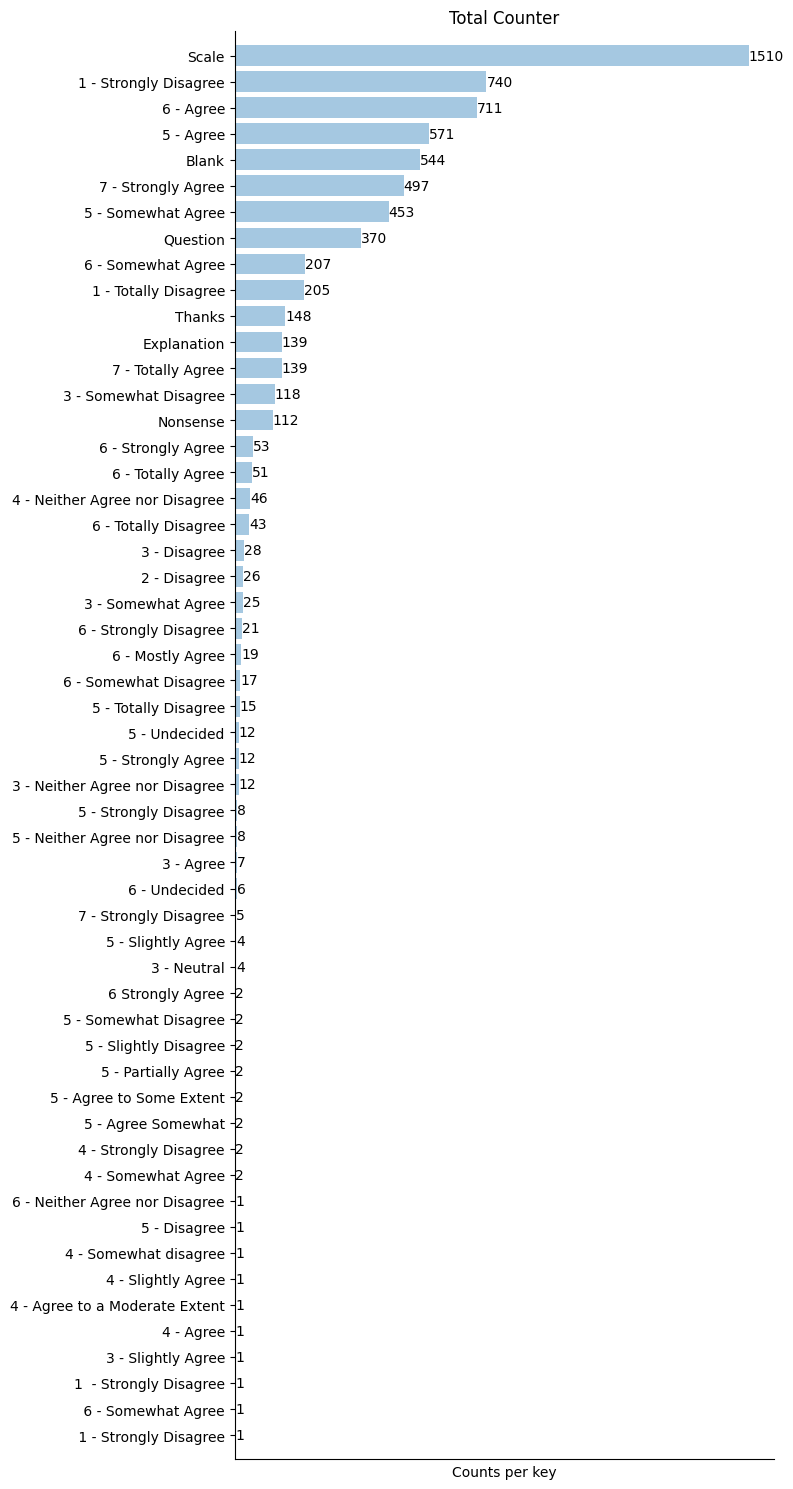

In [202]:
plot_counter(total_counter, "Total Counter")

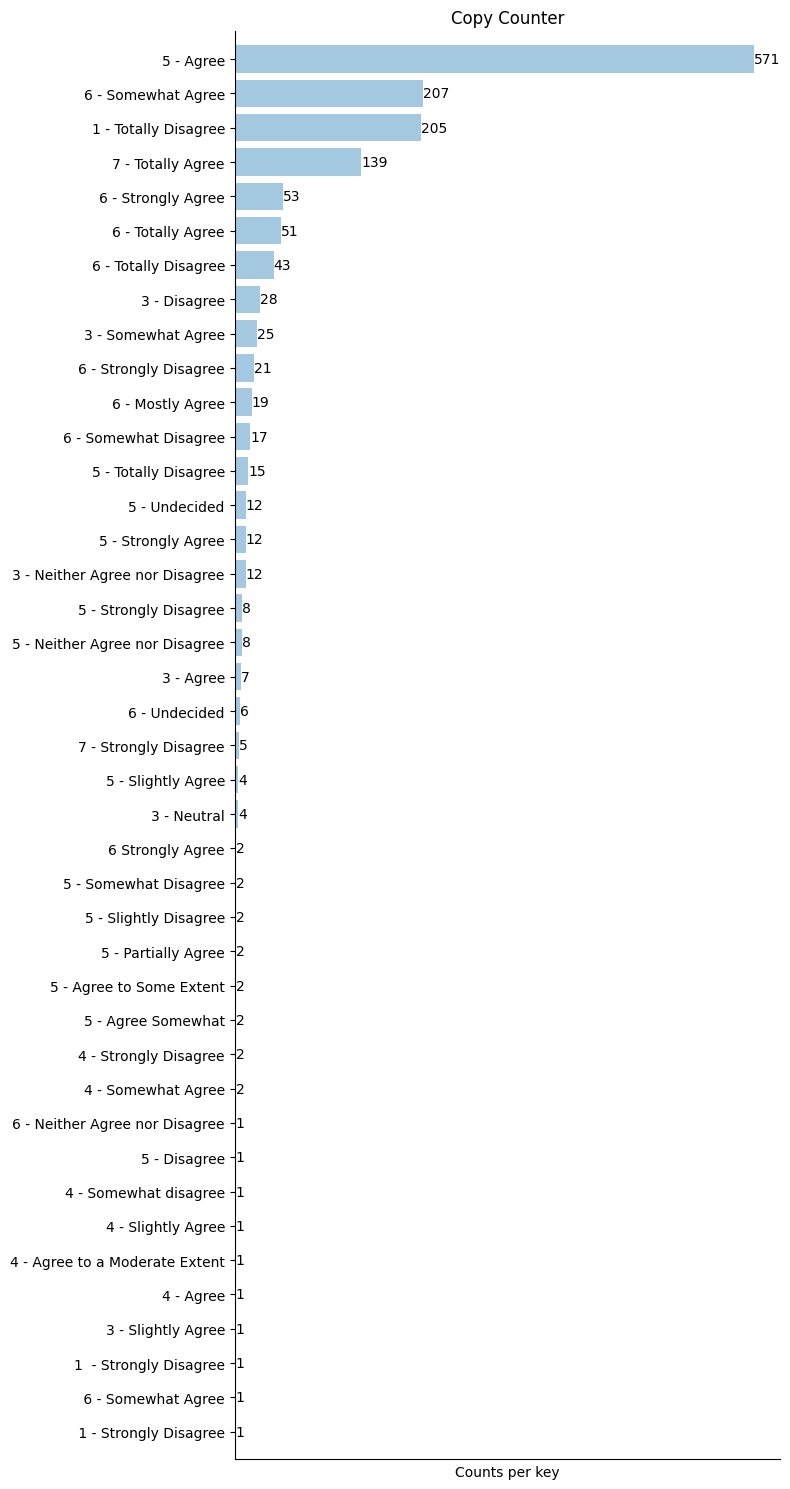

In [203]:
plot_counter(copy_counter, "Copy Counter")